## 基本概念

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings('ignore')

### 简单线性回归

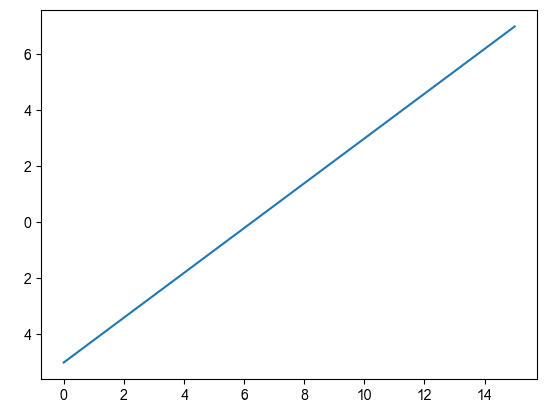

In [2]:
x = np.linspace(0, 15, 50)

plt.plot(x, 0.8 * x - 5)

## 正规方程

### 多元一次方程举例

```
pip install -U scikit-learn
```

#### 二元一次方程

- $x + y = 14$
- $2x - y = 10$

In [3]:
x = np.array([[1, 1], [2, -1]])
y = np.array([14, 10])

**使用 `np.linalg` 求解**

In [4]:
# 1.使用 np.linalg 求解
np.linalg.solve(x, y)

array([8., 6.])

**使用正规方程求解**

$W=(X^TX)^{-1}X^Ty$

In [5]:
# 2.使用正规方程求解
np.linalg.inv(x.T @ x) @ x.T @ y

array([8., 6.])

#### 三元一次方程


- $x - y + z = 100$
- $2x + y - z = 80$
- $3x - 2y + 6z = 256$

In [6]:
x = np.array([[1, -1, 1],
             [2, 1, -1],
             [3, -2, 6]])
y = np.array([100, 80, 256])

In [7]:
np.linalg.solve(x, y)

array([ 60., -41.,  -1.])

In [8]:
np.linalg.inv(x.T @ x) @ x.T @ y

array([ 60., -41.,  -1.])

#### 八元一次方程

In [9]:
x = np.array([[0, 14, 8, 0, 5, -2, 9, -3],
            [-4, 10, 6, 4, -14, -2, -14, 8],
            [-1, -6, 5, -12, 3, -3, 2, -2],
            [5, -2, 3, 10, 5, 11, 4, -8],
            [-15, -15, -8, -15, 7, -4, -12, 2],
            [11, -10, -2, 4, 3, -9, -6, 7],
            [-14, 0, 4, -3, 5, 10, 13, 7],
            [-3, -7, -2, -8, 0, -6, -5, -9]])

y = np.array([339, -114, 30, 126, -395, -87, 422, -309])

In [10]:
np.linalg.solve(x, y)

array([ 1.,  5., 15.,  3.,  8.,  4., 17., 12.])

In [11]:
np.linalg.inv(x.T @ x) @ x.T @ y

array([ 1.,  5., 15.,  3.,  8.,  4., 17., 12.])

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
x = np.array([[0, 14, 8, 0, 5, -2, 9, -3],
            [-4, 10, 6, 4, -14, -2, -14, 8],
            [-1, -6, 5, -12, 3, -3, 2, -2],
            [5, -2, 3, 10, 5, 11, 4, -8],
            [-15, -15, -8, -15, 7, -4, -12, 2],
            [11, -10, -2, 4, 3, -9, -6, 7],
            [-14, 0, 4, -3, 5, 10, 13, 7],
            [-3, -7, -2, -8, 0, -6, -5, -9]])

y = np.array([339, -114, 30, 126, -395, -87, 422, -309])

In [14]:
# fit_intercept 表示是否计算截距。我们提供的八元一次方程没有设置截距，所以不设置
model = LinearRegression(fit_intercept=False)

# 拟合（将机器学习模型与训练数据进行匹配，以学习数据中的模式和关系）
reg = model.fit(x, y)

fit：拟合是指将机器学习模型与训练数据进行匹配，以学习数据中的模式和关系。在拟合过程中，模型会调整自身的参数，以最大程度地减小预测值与实际值之间的差异。通过调用"fit"方法，模型会根据提供的训练数据进行学习，从而使其能够在未见过的数据上进行准确的预测。

In [15]:
# coefficent，系数
reg.coef_

array([ 1.,  5., 15.,  3.,  8.,  4., 17., 12.])

In [16]:
# 截距
reg.intercept_

0.0

#### 带截距的线性方程

In [17]:
reg.coef_

array([ 1.,  5., 15.,  3.,  8.,  4., 17., 12.])

所以八元一次函数为

$f(x) = x_1 + 5 x_2 + 15 x_3 + 3 x_4 + 8 x_5 + 4 x_6 + 17 x_7 + 12 x_8$

---

为其**添加截距** $b=12$

$h(x) = f(x) + 12$

In [18]:
y

array([ 339, -114,   30,  126, -395,  -87,  422, -309])

In [19]:
h = y + 12
h

array([ 351, -102,   42,  138, -383,  -75,  434, -297])

**再次拟合**

In [20]:
m = LinearRegression(fit_intercept=True)
r = m.fit(x, h) # x(8,8), h(8,)
print(r.coef_)
print(r.intercept_)

[ 3.45714358  6.90856568 10.8264159   0.44734523  6.86091921  6.24871714
 17.47728367 12.78738885]
26.928205008398017


**分析：输入八个八元一次方程，加上截距相当于八个九元一次方程组，存在多个解**

- 八个：x 矩阵行数
- 八元：x 矩阵列数

**解决办法：再添加一个方程**

In [21]:
x = np.array([[0, 14, 8, 0, 5, -2, 9, -3],
            [-4, 10, 6, 4, -14, -2, -14, 8],
            [-1, -6, 5, -12, 3, -3, 2, -2],
            [5, -2, 3, 10, 5, 11, 4, -8],
            [-15, -15, -8, -15, 7, -4, -12, 2],
            [11, -10, -2, 4, 3, -9, -6, 7],
            [-14, 0, 4, -3, 5, 10, 13, 7],
            [-3, -7, -2, -8, 0, -6, -5, -9]])
y = np.array([339, -114, 30, 126, -395, -87, 422, -309])

model = LinearRegression(fit_intercept=False)
reg = model.fit(x, y)

In [22]:
r_x = np.random.randint(0, 20, size=(1, 8))
r_x

array([[10, 16,  2, 14, 11,  4, 16,  1]])

In [23]:
x2 = np.concatenate([x, r_x])
x2

array([[  0,  14,   8,   0,   5,  -2,   9,  -3],
       [ -4,  10,   6,   4, -14,  -2, -14,   8],
       [ -1,  -6,   5, -12,   3,  -3,   2,  -2],
       [  5,  -2,   3,  10,   5,  11,   4,  -8],
       [-15, -15,  -8, -15,   7,  -4, -12,   2],
       [ 11, -10,  -2,   4,   3,  -9,  -6,   7],
       [-14,   0,   4,  -3,   5,  10,  13,   7],
       [ -3,  -7,  -2,  -8,   0,  -6,  -5,  -9],
       [ 10,  16,   2,  14,  11,   4,  16,   1]])

In [24]:
y2 = np.concatenate([y, reg.coef_ @ r_x.T])
y2

array([ 339., -114.,   30.,  126., -395.,  -87.,  422., -309.,  550.])

In [25]:
model = LinearRegression(fit_intercept=True)
reg = model.fit(x2, y2 + 12)
print(reg.coef_)
print(reg.intercept_)

[ 1.  5. 15.  3.  8.  4. 17. 12.]
12.000000000000043


## 线性回归实战

### 使用正规方程进行求解

**1. 随机生成样本**

1. 随机生成等差数列
2. 随机生成斜率和截距
3. 根据 $y=xw+b$ 计算 y，添加噪声模拟真实值

**2. 使用正规方程倒推斜率和截距**

已知样本数据，即 $X(30, 1)$ 和 $y(30, 1)$，使用正规方程计算权重 $W$

$W=(X^TX)^{-1}X^Ty$

（也可用 sklearn 提供的线性回归类计算）


真实斜率和截距为 [1] [2]
计算的结果是 [1.04 1.53]


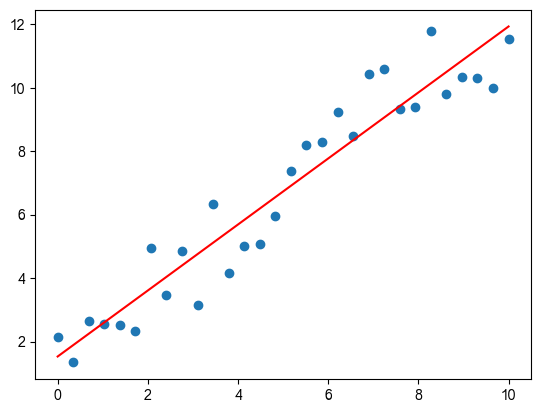

In [26]:
X = np.linspace(0, 10, num = 30).reshape(30, 1) # 等差数列
w = np.random.randint(1, 5, size = 1) # 随机斜率
b = np.random.randint(1, 10, size = 1) # 随机截距
noise = np.random.randn(30, 1) # # 噪声
y = (X * w + noise) + b #计算真实值。添加噪声，模拟真实值
# y(30, 1) = X(30, 1) · w(1, 1) + b(1, 1)

#根据样本数据绘制散点图
plt.scatter(X, y)
#---------------------- 2 -------------------------------------

# X(30, 1) ------添加系数列----->  X(30, 2)。    也可以将系数列放在第一列
X = np.concatenate([X, np.full(shape = (30, 1), fill_value = 1)], axis = 1)

# 使用正规方程求解 W
W = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y).round(2)

print('真实斜率和截距为', w, b)
print('计算的结果是', W.flatten())

# 根据计算出的 w 和 b 绘制“模型”
_ = plt.plot(X[:, 0], X.dot(W), color='red')

**多元线性回归**

真实斜率和截距为 [2 4] [6]
计算的结果是 [2.   4.   6.49]


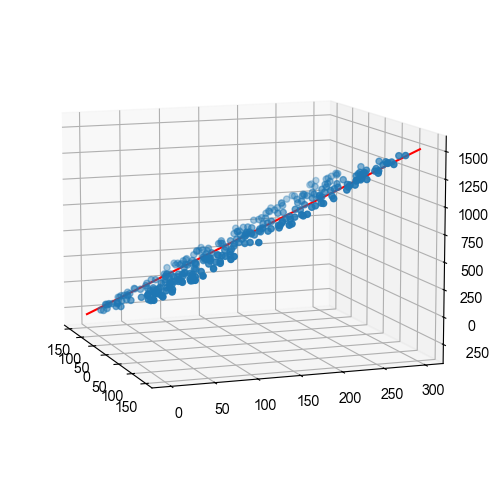

In [27]:
x1 = np.random.randint(-150, 150, size = (300, 1))
x2 = np.random.randint(0, 300, size = (300, 1))

w = np.random.randint(1, 5, size = 2)
b = np.random.randint(1, 10, size = 1)

y = x1 * w[0] + x2 * w[1] + b + np.random.rand(300, 1)

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection = '3d')
ax.scatter(x1, x2, y)
ax.view_init(elev = 10, azim = -20)#调整视角

#------------------------- 2 -------------------------------------

X = np.concatenate([x1, x2, np.full(shape = (300, 1), fill_value = 1)], axis = 1)

# 通过正规方程求解
W = np.linalg.inv(X.T @ X).dot(X.T).dot(y).round(2)

print('真实斜率和截距为', w, b)
print('计算的结果是', W.flatten())

x1 = np.array([[-150], [150]])
x2 = np.array([[0], [300]])
ax.plot(x1, x2, x1 * W[0] + x2 * W[1] + W[2], color = 'red')

### 使用 sklearn 进行求解

In [28]:
from sklearn.linear_model import LinearRegression

真实斜率和截距为 [3] [3]
计算的结果是 [[3.0656547]] [2.80039536]



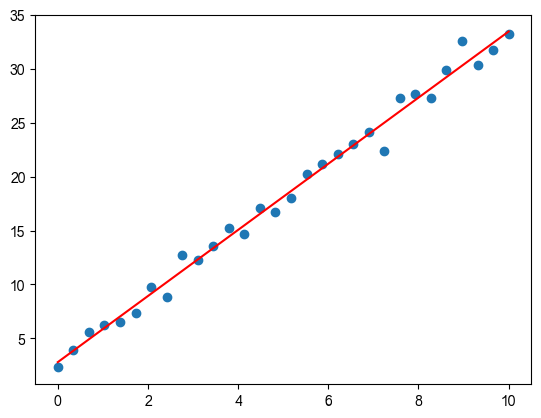

In [29]:
X = np.linspace(0, 10, num = 30).reshape(30, 1) # 等差数列
w = np.random.randint(1, 5, size = 1) # 随机斜率
b = np.random.randint(1, 10, size = 1) # 随机截距
noise = np.random.randn(30, 1) # # 噪声
y = (X * w + noise) + b #计算真实值。添加噪声，模拟真实值
# y(30, 1) = X(30, 1) · w(1, 1) + b(1, 1)

#根据样本数据绘制散点图
plt.scatter(X, y)
#---------------------- 2 -------------------------------------

reg = LinearRegression(fit_intercept=True)
reg.fit(X, y)

print('真实斜率和截距为', w, b)
print('计算的结果是', reg.coef_, reg.intercept_)
print()

# 根据计算出的 w 和 b 绘制“模型”
x_t = np.array([0, 10])
_ = plt.plot(x_t, x_t * reg.coef_[0][0] + reg.intercept_[0], color = 'red')

真实斜率和截距为 [1 2] [2]
计算的结果是 [[1.00002619 2.00004193]] [2.49031856]


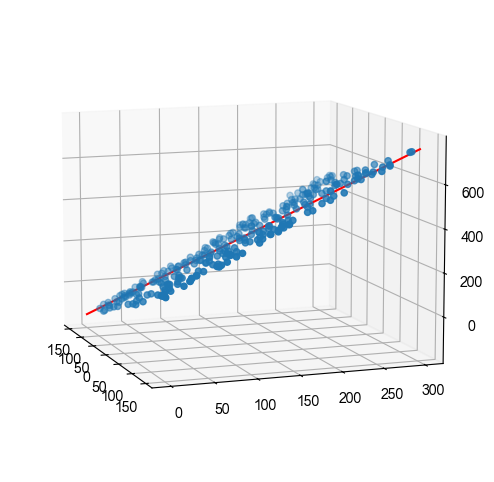

In [30]:
x1 = np.random.randint(-150, 150, size = (300, 1))
x2 = np.random.randint(0, 300, size = (300, 1))

w = np.random.randint(1, 5, size = 2)
b = np.random.randint(1, 10, size = 1)

y = x1 * w[0] + x2 * w[1] + b + np.random.rand(300, 1)

fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection = '3d')
ax.scatter(x1, x2, y)
ax.view_init(elev = 10, azim = -20)#调整视角

#------------------------- 2 -------------------------------------

reg = LinearRegression()
reg.fit(np.concatenate([x1, x2], axis = 1), y)

print('真实斜率和截距为', w, b)
print('计算的结果是', reg.coef_, reg.intercept_)

x1 = np.array([[-150], [150]])
x2 = np.array([[0], [300]])
ax.plot(x1, x2, x1 * reg.coef_[0][0] + x2 * reg.coef_[0][1] + reg.intercept_[0], color = 'red')

## 习题

### No.1

- 气温会随着海拔高度的升高而降低,，我们可以通过测量不同海拔高度的气温来预测海拔高度和气温的关系。
- 我们假设海拔高度和气温的关系可以使用如下公式表达: $y(气温) = w * x(海拔) + b$
- 理论上来讲，确定以上公式 w 和 b的值只需在两个不同高度测试，就可以算出来 w 和 b 的值了。但是由于所有的设备都是有误差的，而使用更多的高度测试的值可以使得预测的值更加准确。
- 我们提供了在9个不同高度测量的气温值，请你根据今天学习的线性回归（正轨方程）方法预测 w 和 b 的值。根据这个公式, 我们预测一下在8000米的海拔, 气温会是多少？

In [31]:
data = np.array([[0.0, 12.834044],
            [500.0, 10.190649],
            [1000.0, 5.500229],
            [1500.0, 2.854665],
            [2000.0, -0.706488],
            [2500.0, -4.065323],
            [3000.0, -7.127480],
            [3500.0, -10.058879],
            [4000.0, -13.206465]])

altitude = data[:, 0]
temperature = data[:, 1]

[[-0.00656953]] [12.71850751]
预测 8000 米海拔的气温为: -39.837766088888884


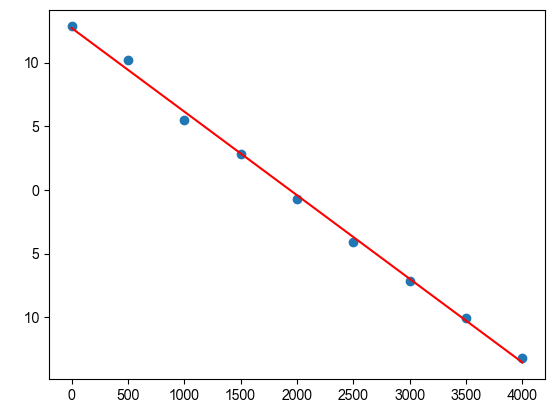

In [32]:
plt.scatter(altitude, temperature)

# ------------------- 计算模型 ------------------------

reg = LinearRegression(fit_intercept=True)
r = reg.fit(altitude.reshape(-1, 1),
       temperature.reshape(-1, 1))
print(r.coef_, r.intercept_)

x = np.array([0, 4000])
plt.plot(x, x * r.coef_[0][0] + r.intercept_[0], color = 'red')

# 预测
print('预测 8000 米海拔的气温为:', r.predict([[8000]])[0][0])

### No.2

https://www.heywhale.com/mw/dataset/64214131a119a32d1b00ecf3

### No.3 房价预测

In [33]:
from sklearn import datasets
import pandas as pd
import numpy as np

1、加载数据

In [34]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

2、查看数据

In [35]:
print(data.shape)#样本，每个样本有 13 个特征
print(target.shape)#价格

(506, 13)
(506,)


3、数据拆分

拆分为 4:1，表示训练集和测试集规模之比

In [36]:
idx = np.arange(506)
np.random.shuffle(idx)#索引打散

train_index = idx[:405] # 506 * 0.8 = 404.8 ≈ 405
test_index = idx[405:]

X_train = data[train_index]
X_test = data[test_index]

y_train = target[train_index]
y_test = target[test_index]

print('train set:', X_train.shape, y_train.shape)
print('test set:', X_test.shape, y_test.shape)

train set: (405, 13) (405,)
test set: (101, 13) (101,)


4、数据建模

In [37]:
np.set_printoptions(suppress=True)
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

# coef_ 表示斜率，其中有正有负，分别表示什么呢？
# 正表示正相关，比如面积、卧室数量；负表示负相关，比如犯罪率、环境污染
display(model.coef_, model.intercept_)

array([ -0.10459456,   0.04667291,   0.03277411,   3.71611215,
       -17.15276206,   4.19308256,  -0.00802844,  -1.43967503,
         0.2728901 ,  -0.00978967,  -0.91482444,   0.00900977,
        -0.52471486])

32.77253629431174

5、模型验证

In [38]:
#预测结果
y_ = model.predict(X_test).round(2)
y_

array([27.6 , 20.54, 24.07, 25.9 ,  5.71, 23.7 , 11.95, 21.51, 14.51,
       27.2 , 24.4 , 10.09, 39.78, 28.62, 36.16, 33.63, 25.86,  9.35,
       25.  , 17.66, 30.69, 22.78, 22.7 , 24.24, 22.59, 28.71, 20.11,
       32.33, 25.57, 29.25, 17.29, 36.99, 20.18,  8.28, 17.5 , 15.27,
       21.29, 13.45, 22.02, 37.16, 13.04, 24.77, 27.26, 19.5 , 11.57,
       12.95, 19.7 , 24.27, 22.82, 16.05, 22.08, 19.01, 17.42, 32.49,
       21.36, 13.89, 20.94, 23.03, 23.44, 22.33, 25.15, 28.99, 21.32,
       17.25,  6.07, 28.7 , 25.43, 25.55, 16.72, 14.91, 13.37, 26.23,
       22.98, 18.24, 31.64, 27.41, 19.89, 15.35, 27.37, 19.24, 20.52,
       13.22, 28.67, 13.81, 35.25, 17.99, 28.54, 20.79, 32.58, 39.43,
       23.62, 14.01, 26.32, 15.22, 21.9 , 25.41, 33.28, 20.39, 30.76,
       36.9 , 27.98])

In [39]:
y_ - y_test

array([  5.6 ,   1.74,   1.87,  -0.6 ,  -8.09,   1.3 ,   6.35,   2.21,
        -0.29,   4.9 ,   2.7 ,   1.79,  17.88,   0.22,  -2.54,   6.63,
        10.86,  -8.45, -25.  ,   3.56,   7.19,   1.58,   2.4 ,  -5.36,
         2.79,   0.71,  -0.39,   0.73,   0.77,   4.25,  -0.51,  -6.11,
         3.98,  -6.12,  -5.  ,  -6.63,   0.29,  -0.05,   2.02, -12.84,
        -0.86,   3.17,  -8.94,   7.  ,  -4.73,   0.25,   0.1 ,   1.17,
        -0.38,  -1.35,   0.98,   0.71,  -1.88,  -0.71,   4.56,   6.39,
         1.34,   3.03,   2.24,   4.93,   6.65,   6.09,   5.72,  -2.75,
        -4.13,   5.  ,  -2.67,  -4.55,  -0.78,  -2.29,   0.27,  -3.57,
         1.98,  -1.26,   0.84,   5.41,   0.79,   0.35,   4.07,   1.24,
         7.42,  -0.28,   5.07,  -0.19,   0.15,   5.29,   5.24,  -3.71,
         1.48,  -4.07,   4.22,  -1.69,   2.52,  -0.98,  -1.4 ,   2.21,
         0.18,   6.59,  -3.94,   1.7 ,   4.08])

6、模型评估

In [40]:
#越接近 1 表示模型越好
model.score(X_test, y_test)

0.6059267047253969

手动计算 score：（根据 score 方法的注释）

<font size=5>$R^2 = 1 - \frac{u}{v}$</font>

$u = \sum (y - \hat y)^2$

$v = \sum (y - y_{mean})^2$

In [41]:
y_pred = model.predict(X_test)
u = ((y_test - y_pred) ** 2).sum()
u

2646.8383915464597

In [42]:
v = ((y_test - y_test.mean()) ** 2).sum()
v

6716.614455445545

In [43]:
1 - u / v

0.6059267047253969

In [44]:
from sklearn.metrics import mean_squared_error

In [45]:
mean_squared_error(y_test, y_pred)

26.20632070838079

----

In [46]:
#查看训练集的评分。分数更高，因为拟合度高
model.score(X_train, y_train)

0.7627642089634599

In [47]:
mean_squared_error(y_train, model.predict(X_train))

21.06347064533334

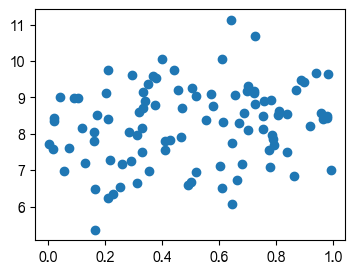

In [48]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

plt.figure(figsize = (4, 3))
_ = plt.scatter(X, y)

In [49]:
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
X.shape

(100, 2)

真实的斜率和截距为 1 8
求出的斜率和截距为 [0.76093453 7.86232066]


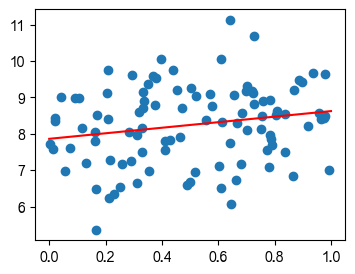

In [50]:
epoches = 10000
eta = 0.01

#要求解的系数
theta = np.random.randn(2, 1)

for i in range(epoches):
    #计算梯度
    g = X.T @ (X @ theta - y)
    #更新 theta
    theta = theta - eta * g

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

**逆时衰减：随着迭代次数添加，一点点变小学习率**

真实的斜率和截距为 1 8
求出的斜率和截距为 [0.76093453 7.86232066]


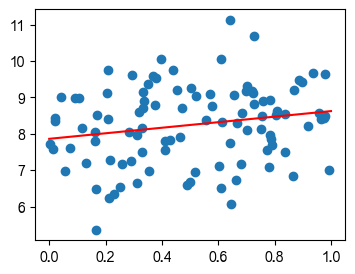

In [51]:
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

times = 0
for i in range(epoches):
    #计算梯度
    g = X.T @ (X @ theta - y)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

<font size=6>$\theta_k^{t+1} = \theta_k^{t} - \alpha * ((\sum \limits_{j=0}^n \theta_jx_j^{(i)} - y^{(i)}) x_k^{(i)})$</font>

#### 一元一次线性回归

真实的斜率和截距为 6 6
求出的斜率和截距为 [5.09657183 6.50557241]


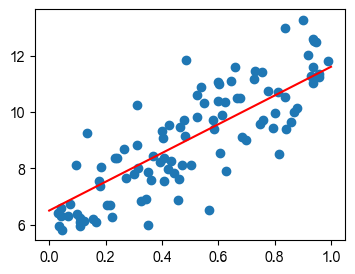

In [52]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

times = 0
for i in range(epoches):
    #随机取出一个样本
    idx = np.random.randint(0, 100, size = 1)[0]
    X_random = X[[idx]] # (1,2)
    y_random = y[[idx]] # (1,1)
    #计算梯度
    g = X_random.T @ (X_random @ theta - y_random)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

#### 多元一次线性回归

In [53]:
m = 100 # 样本数
n = 10 #特征数
X = np.random.rand(m, n)
w = np.random.randint(1, 10, size = (n, 1)) # 随机斜率
b = np.random.randint(1, 10, size = (1, 1))[0] # 随机截距

y = X @ w + b + np.random.randn(m, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (m, 1), fill_value = 1)], axis = 1)

epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 逆时衰减函数
    return t0 / (t + t1)

#要求解的系数数组，[theta_1, theta_2, ..., theta_n, theta_0]，最后一个 theta_0 呼应上边添加的一列
theta = np.random.randn(n + 1, 1)

times += 0
for i in range(epoches):
    #随机取出一个样本
    idx = np.random.randint(0, m, size = 1)[0]
    X_random = X[[idx]] # (1, n+1)
    y_random = y[[idx]] # (1, 1)
    #计算梯度
    g = X_random.T @ (X_random @ theta - y_random)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w.flatten(), b)
print('求出的斜率和截距为', theta.flatten())

真实的斜率和截距为 [4 7 6 9 9 4 3 2 4 9] [5]
求出的斜率和截距为 [ 3.82246028  5.37901058  5.61879157  6.25663722  4.14572374  4.74922081
  3.51209247  4.11539325  3.75799282  5.63340567 10.00478073]


In [54]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

batch_size = 16 # 每批样本数
batch_num = 100 // batch_size # 一共多少批

times = 0
for i in range(epoches):
    #随机取出一批
    batch_idx_start = np.random.randint(0, batch_size * batch_num, size = 1)[0]
    X_batch = X[batch_idx_start : (batch_idx_start + batch_size)]
    y_batch = y[batch_idx_start : (batch_idx_start + batch_size)]
    #计算梯度
    g = X_batch.T @ (X_batch @ theta - y_batch)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

真实的斜率和截距为 6 8
求出的斜率和截距为 [6.06128515 8.01255455]
